## EQUATION DERIVEE PARTIELLE

### 1. RESOLUTION DE L'EQUATION ELLIPTIQUE

C:\Users\User\AppData\Local\Temp\ipykernel_1988\1782979928.py:32: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F ); U [1: NX -1] = Uint


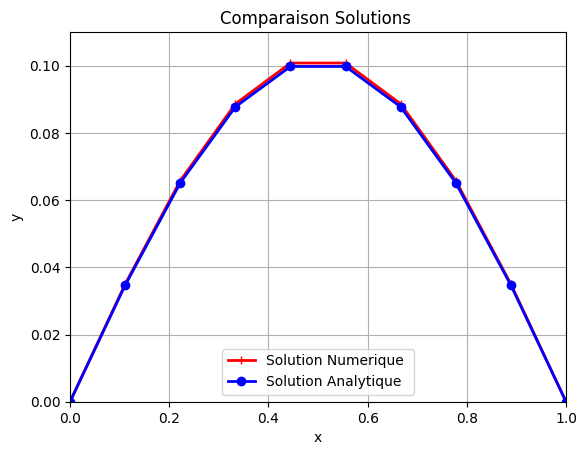

In [1]:
# =============================================
# Resolution de l Equation Elliptique
# -d^2u/dx=f avec x dans ]0 ,1[ , avec
# f(x) = sin(np.pi*x) , et
# la condition a la limite u (0)= u(1) = 0
# ==============================================
# IMPORTAION DES LIBRAIRIES
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm
#%% MAILLAGE DU DOMAINE
NX = 10; x = np.linspace (0.0 ,1 , NX ); dx = 1/( NX -1)
# DEFINITION DE LA FONCTION SOURCE F
def func1 ( x ):
    return ( np.sin(np.pi * x ))
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (( np.sin( np.pi * x ))/( np.pi **2))
Uex = np.vectorize ( func2 )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    U [0] = 0; U [ -1] = 0 # Conditions limites
    F = ( dx **2)* f ( x )
    F = F [1: NX -1]
    val_diags = [ - np.ones ( NX -2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    Uint = spsolve(A , F ); U [1: NX -1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

0.0005016017732329816  : NORME de l’erreur absolue 
0.00017182996533779082  : NORME de l’erreur absolue 
5.9823639569026726e-05  : NORME de l’erreur absolue 
2.0990827196064806e-05  : NORME de l’erreur absolue 
7.393426567893441e-06  : NORME de l’erreur absolue 
Ordre de Convergence en erreur Relative :  1.9756234059365518
Ordre de Convergence en erreur absolue :  1.974947010216945


C:\Users\User\AppData\Local\Temp\ipykernel_1988\1782979928.py:32: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F ); U [1: NX -1] = Uint


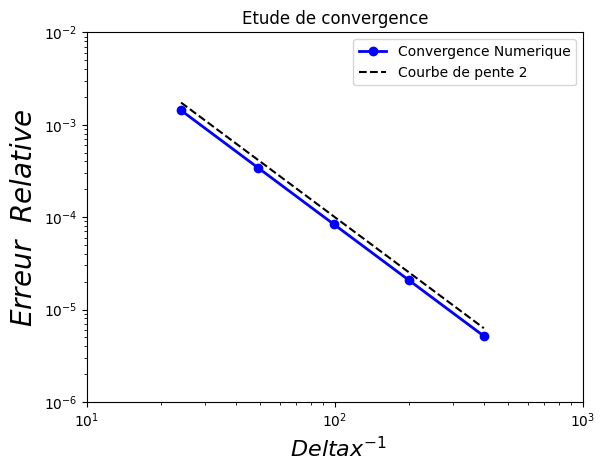

In [2]:
# ====================================================================
#%% ETUDE DE LA CONSISTENCE , DE LA CONVERGENCE EN ESPACE DU SCHEMA
# ====================================================================
NX = np.array ([25 ,50 ,100 ,200 ,400]); dx = 1/( NX -1); NN = NX.size 
ERRABS = np.zeros ( NN ); ERRLAT = np.zeros ( NN )
for k in range (0 , NN ):
    x = np.linspace (0.0 ,1 , NX[ k ])
    UC = U_discret (x , NX[ k ] , dx[ k ] , f )
    Uexact = Uex ( x )
    ERRABS [ k ] = max(abs( UC - Uexact ))
    ERRLAT [ k ] = max(abs ( UC - Uexact )) / max(abs( Uexact ))
    print ( norm(( UC - Uexact )) ," : NORME de l’erreur absolue ")
P1 = np.log (( ERRLAT [1] - ERRLAT [2])/( ERRLAT [2] - ERRLAT [3]))/ np.log ( dx [0]/ dx [1])
print ('Ordre de Convergence en erreur Relative : ', P1 )
P2 = np.log (( ERRABS [1] - ERRABS [2])/( ERRABS [2] - ERRABS [3]))/ np.log ( dx [0]/ dx [1])
print ('Ordre de Convergence en erreur absolue : ', P2 )

fig , ax = plt.subplots (1)
ax.loglog ( dx ** -1 , ERRLAT ,'b-o', lw =2 , label ='Convergence Numerique')
ax.loglog ( dx ** -1 ,1* dx **2 , '--k', label ='Courbe de pente 2')
ax.set_xlabel ('$\ Delta x^{ -1}$', fontsize =16)
ax.set_ylabel ('$Erreur ~~ Relative$ ', fontsize =20)
ax.set_xlim ([10**1 , 10**3])
ax.set_ylim ([10** -6 , 10** -2])
ax.set_title ('Etude de convergence'); ax.legend ()

### SIMULATION VALIDATION

### 1. donner la solution analytique pour 
c = 1 

f(x) = x²exp(x)


alpha = 0 et beta = 0

In [3]:
from sympy import symbols, Function, Eq, dsolve, sin, cos, exp
from sympy.abc import x, C
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm
y = Function('y')

In [4]:
edo3 = Eq(-y(x).diff(x, 2) + 1*y(x), (x**2 ) * exp(x))
solution = dsolve(edo3, ics={y(0): 0, y(1):0})
# solution pour afficher sour forme d'une equation y(x) = 
# print(solution)
solution


Eq(y(x), (-x**3/6 + x**2/4 - x/4 + exp(2)/(-6 + 6*exp(2)))*exp(x) - exp(2)*exp(-x)/(-6 + 6*exp(2)))

In [5]:
NX = 10; x = np.linspace (0.0 ,1 , NX ); dx = 1/( NX -1) # dx=h
# DEFINITION DE LA FONCTION SOURCE F
def func1 ( x ):
    return ((x**2 ) * np.exp(x))
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2(x):
    return ((-x**3/6 + x**2/4 - x/4 + np.exp(2)/(-6 + 6*np.exp(2)))*np.exp(x) - np.exp(2)*np.exp(-x)/(-6 + 6*np.exp(2)))
Uex = np.vectorize ( func2 )

In [6]:
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    U [0] = 0; U [ -1] = 0 # Conditions limites
    F =  f (x)
    F = F [1: NX -1]
    val_diags = [ - np.ones ( NX -2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A1 = (sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2)))
    A2 = np.eye(NX-2,NX-2); 
    A = (1/( dx **2))*A1 + A2
    Uint = spsolve(A , F ); U [1: NX -1] = Uint
    return ( U )

C:\Users\User\AppData\Local\Temp\ipykernel_1988\882380426.py:11: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F ); U [1: NX -1] = Uint


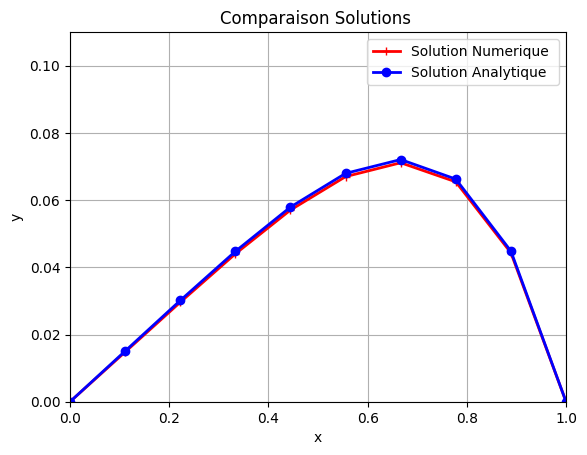

In [7]:
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x ,NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

### 2. donner la solution analytique pour 
c = x² : ici simpy ne pourra pas résoudre c donc on aura qu'une solution numérique 

f(x) = exp(2x)

alpha = 0 et beta = 0

In [8]:
from sympy import symbols, Function, Eq, dsolve, sin, cos, exp
from sympy.abc import x, C
y = Function('y')

In [9]:
edo = Eq(-y(x).diff(x, 2) + (x**2)*y(x), exp(2*x))
solution = dsolve(edo, ics={y(0): 0, y(1):0})
# solution pour afficher sour forme d'une equation y(x) = 
print(solution)
# L'erreur est normale car simpy ne peut pas l'implementer

NotImplementedError: solve: Cannot solve x**2*y(x) - exp(2*x) - Derivative(y(x), (x, 2))

In [27]:
NX = 10; x = np.linspace (0.0 ,1 , NX ); dx = 1/( NX -1) # dx=h
# DEFINITION DE LA FONCTION SOURCE F
def func1 ( x ):
    return np.exp(2*x)
f = np.vectorize ( func1 )
# DEFINITION de C
def func2(x):
    return  (x**2 ) 
c = np.vectorize ( func2 )
C = c(x)

In [29]:
def U_discret (x , NX , dx , f, c ):
    U = np.zeros (( NX ))
    U [0] = 0; U [ -1] = 0 # Conditions limites
    F =  f (x)
    C = c(x)
    F = F [1: NX -1]
    C = C [1: NX -1]
    val_diags = [ - np.ones ( NX -2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A1 = (sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2)))
    A2 = C*np.eye(NX-2,NX-2); 
    A = (1/( dx **2))*A1 + A2
    Uint = spsolve(A , F ); U [1: NX -1] = Uint
    return ( U )

C:\Users\User\AppData\Local\Temp\ipykernel_14660\3116702133.py:13: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F ); U [1: NX -1] = Uint


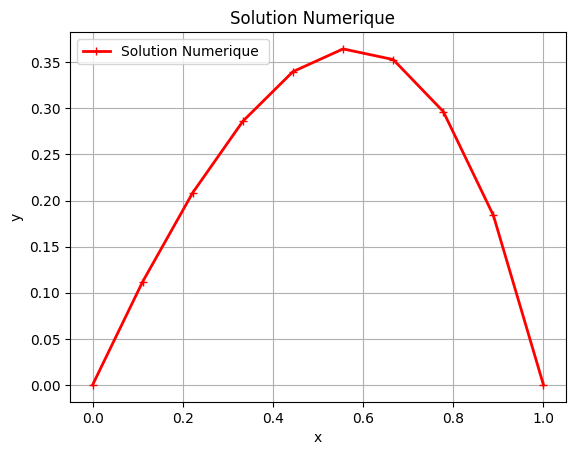

In [30]:
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x ,NX , dx , f, c )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
# ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
# ax.set_xlim ([0 , 1])
# ax.set_ylim ([0 , 0.11])
ax.set_title ('Solution Numerique  ')
ax.legend (); ax.grid ()

## Equation de la chaleur

In [10]:
y = Function('y')

In [11]:
#%% Calcul de la Solution Discrete
def U_discret1 (x , dx , dt , Alpha , NX , NT , U0 ):
    U = np.zeros (( NX , NT ))
    U [: ,0] = U0 ( x ); U [0 ,:] = 0; U [ -1 ,:] = 0
    N = NX -1; gamma = ( Alpha * dt )/( dx **2)
    A = np.diagflat ((1 -2* gamma )* np.ones (N -1) , k =0) \
    + np.diagflat ( gamma * np.ones (N -2) , k =1)+ np.diagflat ( gamma * np.ones (N -2) , k = -1)
    for n in range (0 , NT -1):
        U [1: N , n +1] = np.dot (A , U [1: N , n ])
    return ( U )
def U_discret2 (x , dx , dt , Alpha , NX , NT , U0 ):
    U = np.zeros (( NX , NT ))
    U [: ,0] = U0 ( x );    U [0 ,:] = 0; U [ -1 ,:] = 0
    N = NX -1; gamma = ( Alpha * dt )/( dx **2)
    A = np.diagflat ((1+2* gamma )* np.ones (N -1) , k =0) \
    + np.diagflat ( - gamma * np.ones (N -2) , k =1)+ np.diagflat ( - gamma * np.ones (N -2) , k = -1)
    Ainv = np.linalg.inv ( A )
    for n in range (0 , NT -1):
        U [1: N , n +1] = np.dot ( Ainv , U [1: N , n ])
    return U

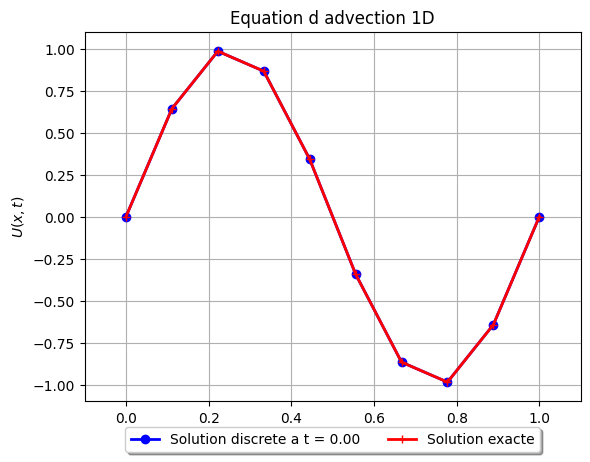

In [26]:
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
NX = 10; x = np.linspace (0.0 ,1 , NX ); dx = 1/( NX -1) # dx=h
# NX = 100;  
# x = np.linspace(0.0,1,NX);dx = 1/(NX-1)  
CFLT = 0.5 
NT = 10
NC = 1
alpha = 0.5
dt = CFLT*(dx**2)/alpha; NTT = int(np.floor(1/dt))+1  
Lambda = (alpha*dt)/(dx**2)
a = 0; b = 1
# Condition Limite

def Ulim(t):
    return(np.sin(10*np.pi*t))

def U0(x):
    return np.sin(2*np.pi*x)

def Uex(a,b,x,t,alpha,U0,Ulim):
    return np.sin(2*np.pi*x) * (np.exp(-4*((np.pi)**2)*0.5*t))

UU = U_discret1 (x ,dx, dt, alpha, NX , NT , U0 )
t  = 0

for n in range(0,NT):

    Uexact = Uex(a,b,alpha,x,t,U0,Ulim)

    if (n%10 == 0): 

        fig, ax = plt.subplots(1) 

        labe = "Solution discrete a t = %1.2f" %(n * dt); 

        ax.plot(x, UU[:,n],'b-o',lw=2, label = labe)

        ax.plot(x, Uexact,'r-+',lw=2, label = 'Solution exacte')

        plt.xlabel('$x$', fontsize=8);plt.ylabel('$U(x,t)$', fontsize=10)

        plt.title('Equation d advection 1D');

        plt.ylim([-1.1, 1.1])

        plt.xlim([-0.1, 1.1])

        plt.grid()

        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), shadow=True, ncol=2);

        filename = "ADVECT22/Figure_" + str(int(n/10)) + ".pdf"

        #plt.savefig(filename)

    t = t+dt 

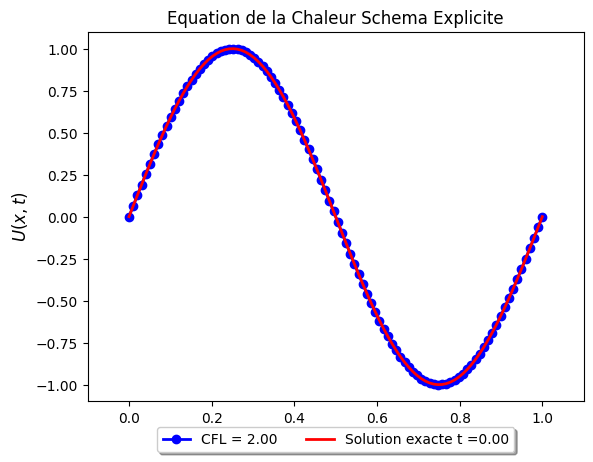

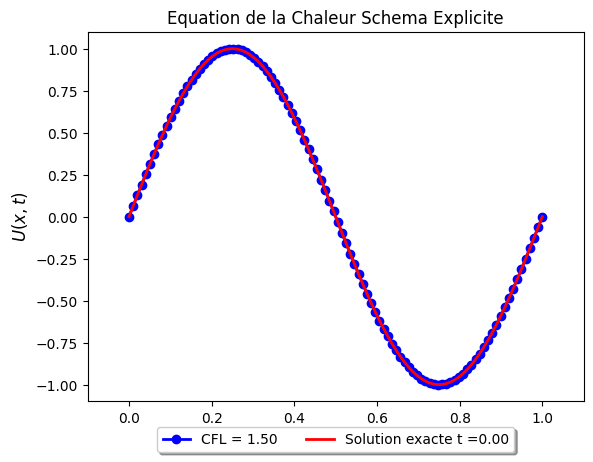

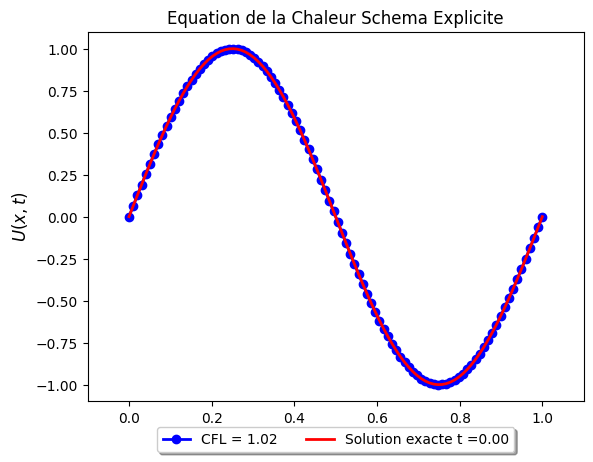

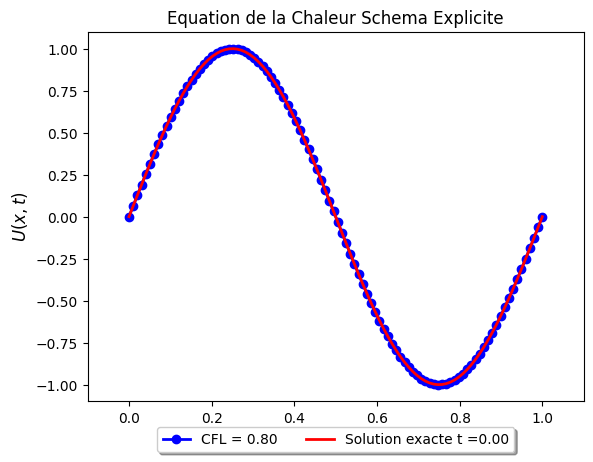

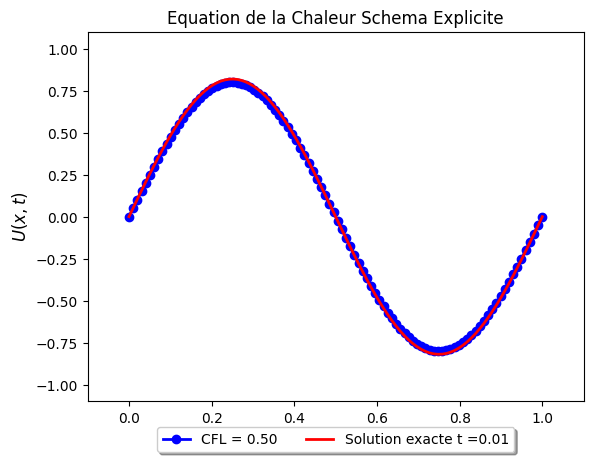

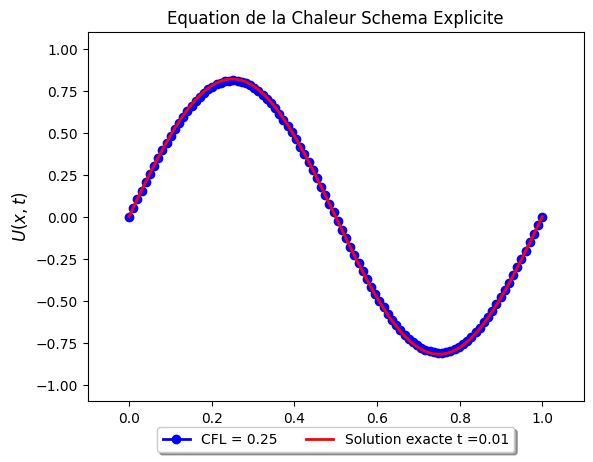

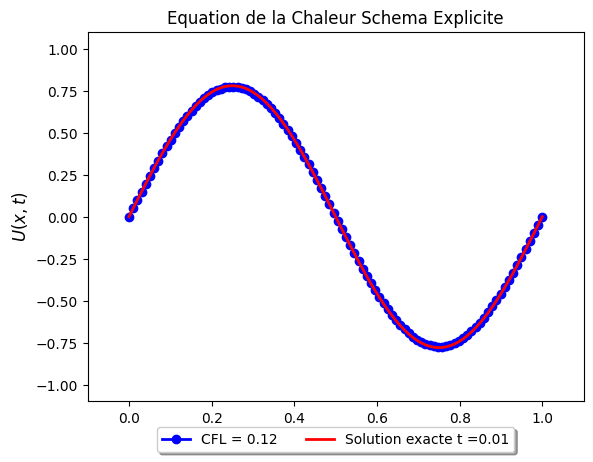

In [36]:
# %%============================================================================        

# ETUDE DE LA STABILITE DU SCHEMA

# ============================================================================

# Il est question d etudier la condition CFL du Probleme

# La variable CFL = (c*dt)/dx prendra trois valeurs (>1, 1, <1)

# afin de tester la condition CFL<=1 et de voir la stabilite du schema

# pour des pas de temps differents
def Uex(x,t,alpha):
    return np.sin(2*np.pi*x) * (np.exp(-4*((np.pi)**2)*0.5*t))

NX = 100;  x = np.linspace(0.0,1,NX);dx = 1/(NX-1)  
CFLT = np.array([2,1.5, 1.02,0.8, 0.5, 0.25,0.125])
# NT = 500
N = CFLT.size
Tf = 0.015
dt = CFLT*dx/alpha; NTT = np.zeros(NC)      
Lambda = (alpha*dt)/dx
for k in range(0,N):
    NT = int(np.floor(Tf/dt[k]) )+ 1
    US = U_discret1(x,dx,dt[k], alpha,NX, NT,U0)
    t  = 0

    for n in range(0,NT):
          Uexact = Uex(x,t,alpha)
          t=t+dt[k]
    fig, ax = plt.subplots(1)  
    labe = "CFL = %1.2f" %CFLT[k]
    ax.plot(x, US[:,n],'b-o',lw=2, label = labe)
    ax.plot(x, Uexact,'r-',lw=2, label = 'Solution exacte t =%1.2f' %(n * dt[k]))

    plt.xlabel('$x$', fontsize=16);plt.ylabel('$U(x,t)$', fontsize=12)

    plt.title('Equation de la Chaleur Schema Explicite')

    plt.ylim([-1.1, 1.1]); plt.xlim([-0.1, 1.1])

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), shadow=True, ncol=2)

    # filename = "ADVECT44/Figure-" +str(CFLT[k]) + "_"+ str(int(n/10))+".pdf"

    # # plt.savefig(filename);

    # t = t+dt[k] 